In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom

jax.config.update("jax_platform_name", "cpu")

import matplotlib.pyplot as plt

from probjax.utils.odeint import _odeint
from probjax.utils.jaxutils import ravel_args
from probjax.core import joint_sample, log_potential_fn,rv 
from probjax.distributions import Normal, Uniform, Independent, MultivariateNormal
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.inference.mcmc import MCMC 
from probjax.inference.marcov_kernels import HMCKernel, GaussianMHKernel, SliceKernel, LangevianMHKernel, LangevianDynamicsKernel

from functools import partial

In [2]:
ts_dense = jnp.linspace(0, 50, 100)

def rbf_kernel(x1, x2, l = 6., sigma_f=3.):
    dists = (x1[None, :]- x2[:, None])**2
    return sigma_f**2 * jnp.exp(-0.5 * dists / l**2) + 1e-5 * jnp.eye(x1.shape[0])

def betas_gp(key, t, kernel_fn=rbf_kernel):
    K = kernel_fn(t,t)
    p0 = MultivariateNormal(jnp.zeros_like(t), K)
    p = TransformedDistribution(p0, lambda x: jax.nn.sigmoid(x))
    return rv(p, name="theta2")(key)

def beta_fn(t,ts, betas):
    y = jnp.interp(t, ts, betas)
    return y

def sir_model(t, y, gamma, delta, betas, ts_betas):
    S, I, R,D = y
    dSdt = -beta_fn(t, ts_betas,betas) * S * I
    dIdt = beta_fn(t, ts_betas,betas) * S * I - (gamma + delta) * I
    dRdt = gamma * I
    dDdt = delta * I
    return dSdt, dIdt, dRdt,dDdt


betas = betas_gp(jrandom.PRNGKey(3), ts_dense)
gamma = 0.1
delta = 0.01
S0 = 1.
R0 = 0.
D0 = 0.
I0 = jax.random.uniform(jrandom.PRNGKey(1), (1,), minval=0., maxval=0.1)[0]

S, I, R,D = _odeint(sir_model, (S0, I0, R0,D0), ts_dense, gamma, delta, betas, ts_dense)

In [29]:
def model(key, ts1, ts2, ts3, ts4, ode_method="rk4", ode_ts_grid=ts_dense):
    key_theta0, key_theta1, key_theta2 , key_I, key_D, key_R = jrandom.split(key, 6)
    prior_gamma_delta = Uniform(jnp.zeros(1), jnp.array([0.5]))
    theta0 = rv(prior_gamma_delta, name="theta0")(key_theta0)
    theta1 = rv(prior_gamma_delta, name="theta1")(key_theta1)
    theta3 = betas_gp(key_theta2, ts1)
    
    S0 = 1.
    R0 = 0.
    D0 = 0.
    I0 = jax.random.uniform(key_I, (), minval=0., maxval=0.2)
    S, I, R, D = _odeint(sir_model, (S0, I0, R0,D0), ode_ts_grid, theta0, theta1, theta3, ts1, method=ode_method)
    
    
    I = jnp.interp(ts2, ode_ts_grid, I)
    R = jnp.interp(ts3, ode_ts_grid, R)
    D = jnp.interp(ts4, ode_ts_grid, D)
    
    I_log = jnp.log(I + 1e-8)
    R_log = jnp.log(R + 1e-8)
    D_log = jnp.log(D + 1e-8)
    
    p_observed1 = TransformedDistribution(Independent(Normal(I_log, 0.05), 1), lambda x: jnp.exp(x))
    p_observed2 = TransformedDistribution(Independent(Normal(R_log, 0.05), 1), lambda x: jnp.exp(x))
    p_observed3 = TransformedDistribution(Independent(Normal(D_log, 0.05), 1), lambda x: jnp.exp(x))
    I_obs = rv(p_observed1, name="x0")(key_I)
    R_obs = rv(p_observed2, name="x1")(key_D)
    D_obs = rv(p_observed3, name="x2")(key_R)
    

In [30]:
joint_sampler = joint_sample(model)

In [31]:
var_names = ["theta0", "theta1", "theta2", "x0", "x1", "x2"]

In [92]:
@partial(jax.vmap, in_axes = [0, None, None, None, None, None,None])
def sample_fn(key, condition_mask, x_o, *x_meta_data):

    conditioned_names = [var_names[i] for i in range(len(var_names)) if condition_mask[i]]
    conditioned_nodes = {var: val for var, val in zip(conditioned_names, x_o)}
    

    init_vals = joint_sampler(key, *x_meta_data)

    for var in conditioned_nodes:
        del init_vals[var]

    init_vals_flat, unravel = ravel_args(init_vals)
    potential_fn = log_potential_fn(model, *x_meta_data)


    @jax.jit
    def potential_fn_wrapper(vals):
        vals = unravel(vals)
        return potential_fn(**vals, **conditioned_nodes)

    kernel = SliceKernel(step_size=0.5, num_steps=20)
    state = kernel.init_state(key,init_vals_flat)
    mcmc = MCMC(kernel, potential_fn_wrapper)
    #mcmc2 = MCMC(kernel2, potential_fn_wrapper)
    samples, state = mcmc.run(state, 20000)
    #samples, state = mcmc2.run(state, 200)
    return unravel(samples)

In [102]:
ts_beta = ts_dense[::3]

sample = joint_sampler(jax.random.PRNGKey(4), ts_beta,ts_dense, ts_dense, ts_dense)

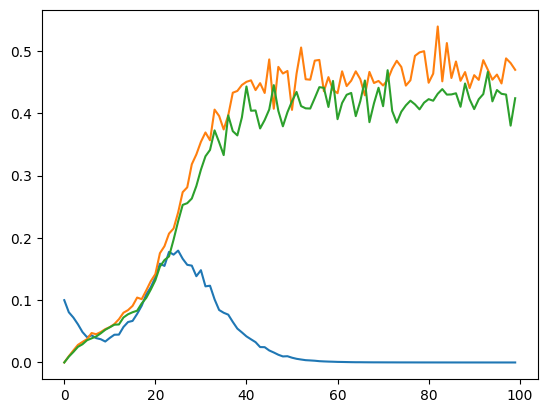

In [103]:
plt.plot(sample["x0"])
plt.plot(sample["x1"])
plt.plot(sample["x2"])

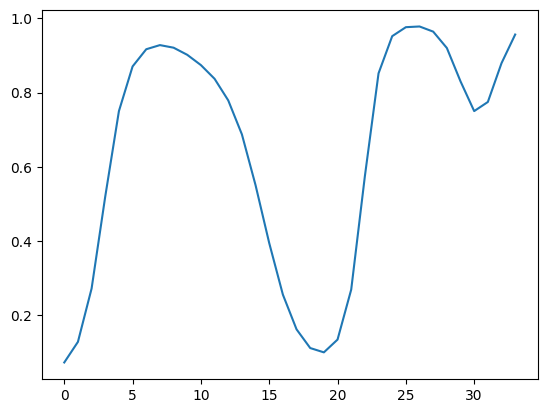

In [104]:
plt.plot(sample["theta2"])

In [105]:
keys = jrandom.split(jrandom.PRNGKey(1), 10)

In [106]:
observe_every= 1
samples = sample_fn(keys, jnp.array([False, False, False, True, True, True]), (sample["x0"][::observe_every], sample["x1"][::observe_every], sample["x2"][::observe_every]), ts_beta, ts_dense[::observe_every], ts_dense[::observe_every],ts_dense[::observe_every])

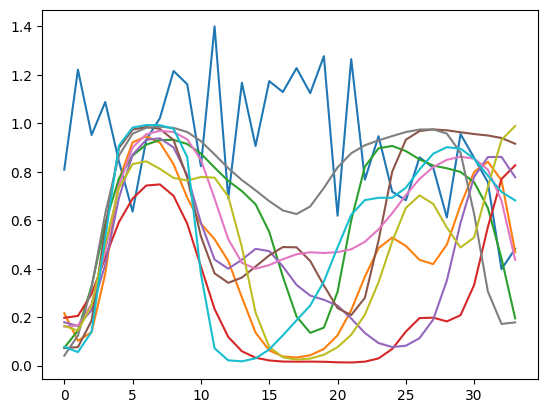

In [107]:
_ = plt.plot(samples["theta2"].T)

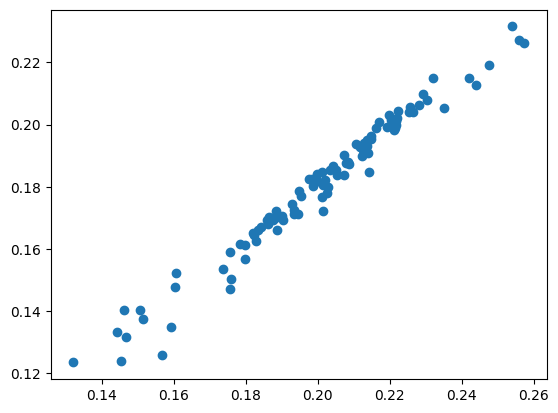

In [91]:
plt.scatter(samples["theta0"], samples["theta1"])

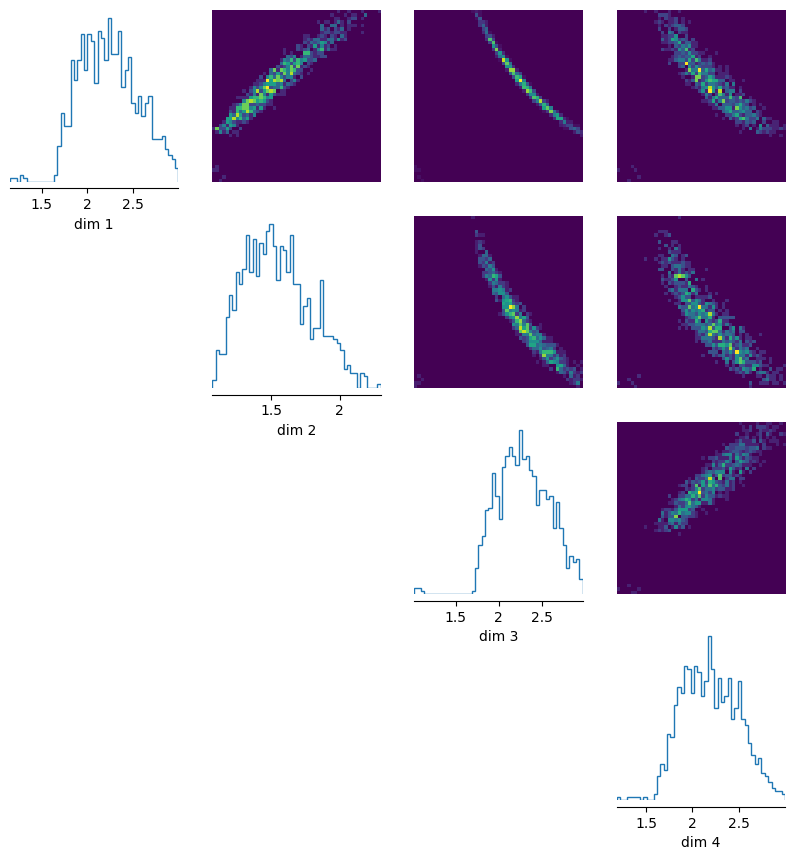

In [12]:
from sbi.analysis import pairplot
import numpy as np


_ = pairplot(np.array(samples))

In [ ]:
samp

In [13]:
sample = joint_sampler(jax.random.PRNGKey(1), ts_dense,ts_dense)

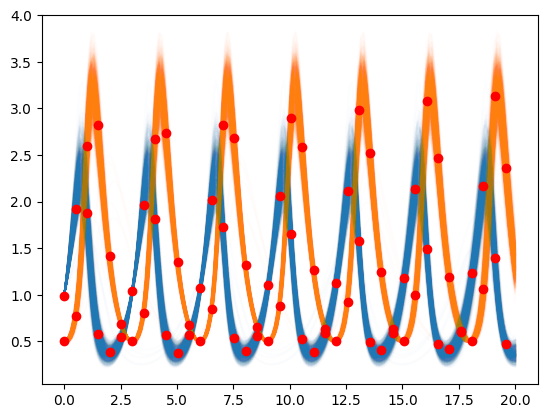

In [14]:
predator, prey = simulator(samples)

_ = plt.plot(ts_dense,predator.T, color="C0", alpha=0.01)
_ = plt.plot(ts_dense,prey.T, color="C1", alpha=0.01)
_ = plt.plot(ts_dense[::observe_every], sample["x0"][::observe_every], "o", color="red")
_ = plt.plot(ts_dense[::observe_every], sample["x1"][::observe_every], "o", color="red")